In [2]:
from pathlib import Path

import numpy as np
import scanpy as sc
import anndata as ad
import h5py
import time
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings("ignore")


In [3]:
adata = sc.read_h5ad("raw/my_norman.h5ad")

In [5]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [4]:
adata

AnnData object with n_obs × n_vars = 101719 × 33694
    obs: 'guide_identity', 'UMI_count', 'gemgroup', 'number_of_cells', 'guide_merged'
    var: 'gene_symbols'

In [11]:
# 先把 gene symbol 设为 var_names
adata.var_names = adata.var["gene_symbols"].astype(str)
adata.var_names_make_unique()


In [12]:
print(adata.var_names[:20].tolist())
print(adata.var.head())

# 看看是不是全小写
print(sum(v.islower() for v in adata.var_names[:100]))
print(sum(v.isupper() for v in adata.var_names[:100]))


['RP11-34P13.3', 'FAM138A', 'OR4F5', 'RP11-34P13.7', 'RP11-34P13.8', 'RP11-34P13.14', 'RP11-34P13.9', 'FO538757.3', 'FO538757.2', 'AP006222.2', 'RP5-857K21.15', 'RP4-669L17.2', 'RP4-669L17.10', 'OR4F29', 'RP5-857K21.4', 'RP5-857K21.2', 'OR4F16', 'RP11-206L10.4', 'RP11-206L10.9', 'FAM87B']
              gene_symbols
gene_symbols              
RP11-34P13.3  RP11-34P13.3
FAM138A            FAM138A
OR4F5                OR4F5
RP11-34P13.7  RP11-34P13.7
RP11-34P13.8  RP11-34P13.8
0
98


In [13]:
s_genes = [
    "MCM5","PCNA","TYMS","FEN1","MCM2","MCM4","RRM1","UNG","GINS2","MCM6",
    "CDCA7","DTL","PRIM1","UHRF1","MLF1IP","HELLS","RFC2","RPA2","NASP","RAD51AP1",
    "GMNN","WDR76","SLBP","CCNE2","UBR7","POLD3","MSH2","ATAD2","RAD51","RRM2",
    "CDC45","CDC6","EXO1","TIPIN","DSCC1","BLM","CASP8AP2","USP1","CLSPN","POLA1",
    "CHAF1B","BRIP1","E2F8"
]

g2m_genes = [
    "HMGB2","CDK1","NUSAP1","UBE2C","BIRC5","TPX2","TOP2A","NDC80","CKS2","NUF2",
    "CKS1B","MKI67","TMPO","CENPF","TACC3","FAM64A","SMC4","CCNB2","CKAP2L","CKAP2",
    "AURKB","BUB1","KIF11","ANP32E","TUBB4B","GTSE1","KIF20B","HJURP","CDCA3","HN1",
    "CDC20","TTK","CDC25C","KIF2C","RANGAP1","NCAPD2","DLGAP5","CDCA2","CDCA8","ECT2",
    "KIF23","HMMR","AURKA","PSRC1","ANLN","LBR","CKAP5","CENPE","CTCF","NEK2",
    "G2E3","GAS2L3","CBX5","CENPA"
]

alias_map = {
    "MLF1IP": "CENPU",
    "FAM64A": "PIMREG",
    "HN1": "JPT1",
}

s_genes_aug = list(dict.fromkeys(s_genes + [alias_map[g] for g in s_genes if g in alias_map]))
g2m_genes_aug = list(dict.fromkeys(g2m_genes + [alias_map[g] for g in g2m_genes if g in alias_map]))

s_genes_use = [g for g in s_genes_aug if g in adata.var_names]
g2m_genes_use = [g for g in g2m_genes_aug if g in adata.var_names]

print("Matched S genes:", len(s_genes_use))
print("Matched G2M genes:", len(g2m_genes_use))
print("Some matched S genes:", s_genes_use[:10])
print("Some matched G2M genes:", g2m_genes_use[:10])


sc.tl.score_genes_cell_cycle(
    adata,
    s_genes=s_genes_use,
    g2m_genes=g2m_genes_use,
)


print(adata.obs["phase"].value_counts())
print(adata.obs["phase"].value_counts(normalize=True))


Matched S genes: 43
Matched G2M genes: 54
Some matched S genes: ['MCM5', 'PCNA', 'TYMS', 'FEN1', 'MCM2', 'MCM4', 'RRM1', 'UNG', 'GINS2', 'MCM6']
Some matched G2M genes: ['HMGB2', 'CDK1', 'NUSAP1', 'UBE2C', 'BIRC5', 'TPX2', 'TOP2A', 'NDC80', 'CKS2', 'NUF2']
phase
G2M    49254
S      32607
G1     19858
Name: count, dtype: int64
phase
G2M    0.484216
S      0.320560
G1     0.195224
Name: proportion, dtype: float64


In [20]:
#ct_celltype = pd.crosstab(adata.obs["cell_type"], adata.obs["phase"], normalize="index")
#ct_sample = pd.crosstab(adata.obs["sample"], adata.obs["phase"], normalize="index")
ct_treatment = pd.crosstab(adata.obs["guide_merged"], adata.obs["phase"], normalize="index")
#ct_donor = pd.crosstab(adata.obs["donor"], adata.obs["phase"], normalize="index")

# print(ct_celltype.head())
# print(ct_sample.head())
print(ct_treatment.head())
#print(ct_donor.head())


phase               G1       G2M         S
guide_merged                              
AHR+FEV       0.350195  0.392996  0.256809
AHR+KLF1      0.130820  0.514412  0.354767
AHR+ctrl      0.212355  0.459459  0.328185
ARID1A+ctrl   0.327014  0.436019  0.236967
ARRDC3+ctrl   0.140659  0.496703  0.362637


In [ ]:
print(ct_celltype)

In [21]:
print(ct_treatment)

phase               G1       G2M         S
guide_merged                              
AHR+FEV       0.350195  0.392996  0.256809
AHR+KLF1      0.130820  0.514412  0.354767
AHR+ctrl      0.212355  0.459459  0.328185
ARID1A+ctrl   0.327014  0.436019  0.236967
ARRDC3+ctrl   0.140659  0.496703  0.362637
...                ...       ...       ...
ctrl+TGFBR2   0.108753  0.527851  0.363395
ctrl+UBASH3A  0.145714  0.528571  0.325714
ctrl+UBASH3B  0.177281  0.523236  0.299484
ctrl+ZBTB1    0.198083  0.495208  0.306709
ctrl+ZBTB25   0.144828  0.479310  0.375862

[284 rows x 3 columns]


In [24]:
df = ct_treatment.reset_index().copy()

def perturb_type(x):
    if x == "ctrl":
        return "ctrl"
    elif "+" in x:
        g1, g2 = x.split("+")
        if g1 == "ctrl" or g2 == "ctrl":
            return "single"
        else:
            return "double"
    else:
        # 保险起见：如果出现没有 + 且不是 ctrl 的情况
        return "single"

df["perturb_type"] = df["guide_merged"].apply(perturb_type)

summary = df.groupby("perturb_type")[["G1", "G2M", "S"]].mean()
summary["n_guides"] = df.groupby("perturb_type").size()
summary = summary.reindex(["ctrl", "single", "double"])

print(summary)


phase               G1       G2M         S  n_guides
perturb_type                                        
ctrl          0.092079  0.541394  0.366528         1
single        0.203000  0.482527  0.314473       152
double        0.274757  0.436988  0.288255       131


In [ ]:
print(ct_donor)

In [ ]:
adata["cytokine"].value_counts()

In [13]:
adata = sc.read_h5ad("raw/Parse_10M_PBMC_cytokines.h5ad")

In [3]:
adata

AnnData object with n_obs × n_vars = 9697974 × 40352
    obs: 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_wind', 'bc2_wind', 'bc3_wind', 'bc1_well', 'bc2_well', 'bc3_well', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_MT', 'pct_counts_MT', 'log1p_total_counts_MT', 'donor', 'cytokine', 'treatment', 'cell_type'
    var: 'n_cells'

In [4]:
adata = adata[adata.obs["donor"]=="Donor11"].copy()

In [5]:
adata

AnnData object with n_obs × n_vars = 613365 × 40352
    obs: 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_wind', 'bc2_wind', 'bc3_wind', 'bc1_well', 'bc2_well', 'bc3_well', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_MT', 'pct_counts_MT', 'log1p_total_counts_MT', 'donor', 'cytokine', 'treatment', 'cell_type'
    var: 'n_cells'

In [4]:
adata.layers["counts"] = adata.X.copy()  # Making sure we keep access to the raw counts

In [14]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [6]:
sc.pp.highly_variable_genes(adata,n_top_genes=2000)

In [7]:
adata = adata[:, adata.var['highly_variable']]

In [8]:
adata

View of AnnData object with n_obs × n_vars = 9697974 × 2000
    obs: 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_wind', 'bc2_wind', 'bc3_wind', 'bc1_well', 'bc2_well', 'bc3_well', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_MT', 'pct_counts_MT', 'log1p_total_counts_MT', 'donor', 'cytokine', 'treatment', 'cell_type'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'
    layers: 'counts'

In [9]:
donor_rep_keys = "donor_one_hot"
mapping = {f"Donor{i+1}": i+1 for i in range(12)}
adata.obs[donor_rep_keys] = adata.obs["donor"].map(mapping).astype("int16")
adata.obs[donor_rep_keys].value_counts()
adata.write_h5ad(f"raw/PBMC_all_hvg2000.h5ad")

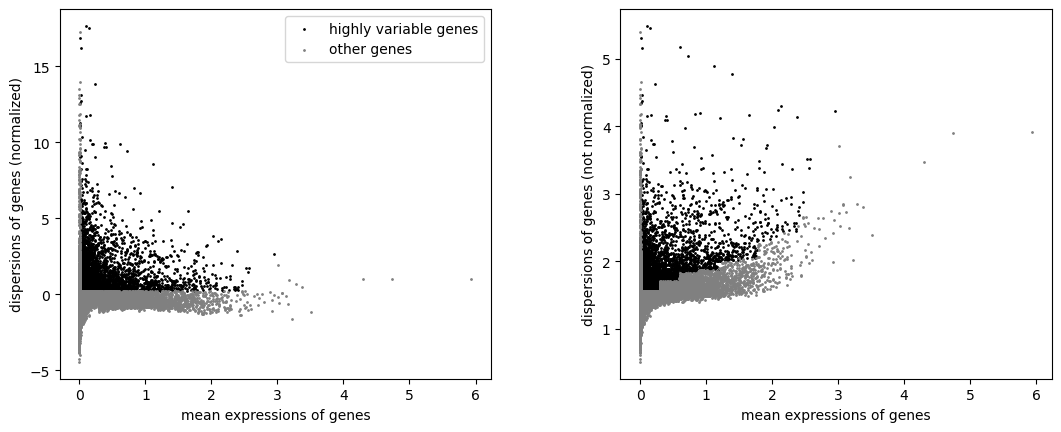

In [5]:
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.25)
sc.pl.highly_variable_genes(adata) 

In [6]:
adata = adata[:, adata.var['highly_variable']]

In [ ]:
#adata.var['highly_variable'].value_counts()

In [7]:
adata

View of AnnData object with n_obs × n_vars = 9697974 × 5412
    obs: 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_wind', 'bc2_wind', 'bc3_wind', 'bc1_well', 'bc2_well', 'bc3_well', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_MT', 'pct_counts_MT', 'log1p_total_counts_MT', 'donor', 'cytokine', 'treatment', 'cell_type'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'

In [8]:
donor_rep_keys = "donor_one_hot"
mapping = {f"Donor{i+1}": i+1 for i in range(12)}
adata.obs[donor_rep_keys] = adata.obs["donor"].map(mapping).astype("int16")
adata.obs[donor_rep_keys].value_counts()

donor_one_hot
1     1267690
5     1066725
12    1054708
6      974030
2      931569
3      695158
7      652386
8      650974
9      632341
11     613365
10     580786
4      578242
Name: count, dtype: int64

In [ ]:
adata.write_h5ad(f"raw/PBMC_all_hvg.h5ad")

## pca

In [2]:
adata = sc.read_h5ad("raw/PBMC_all_hvg.h5ad")

In [10]:
adata

AnnData object with n_obs × n_vars = 9697974 × 2000
    obs: 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_wind', 'bc2_wind', 'bc3_wind', 'bc1_well', 'bc2_well', 'bc3_well', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_MT', 'pct_counts_MT', 'log1p_total_counts_MT', 'donor', 'cytokine', 'treatment', 'cell_type', 'donor_one_hot'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'
    layers: 'counts'

In [11]:
control_key = "is_control"
condition_keys = "cytokine"
condition_rep_keys = "condition_embeddings"

In [12]:
adata.obs[control_key] = (adata.obs[condition_keys] == "PBS")
condition_list = adata[adata.obs[control_key]==False].obs[condition_keys].unique()

In [13]:
random_seed = 42
rng = np.random.default_rng(random_seed) 
test_ratio = 0.2
condition_list = list(condition_list)
zero_shot = True
n_test = max(1, int(len(condition_list) * test_ratio))
test_condition = rng.choice(condition_list, size=n_test, replace=False).tolist()
print(test_condition)
train_condition = [g for g in condition_list if g not in test_condition]

['PRL', 'TRAIL', 'EGF', 'CD27L', 'IL-32-beta', 'IL-6', 'IL-11', 'SCF', 'IL-17F', 'OSM', 'IL-19', 'CD30L', 'IL-36Ra', 'IL-21', 'IL-7', 'G-CSF', 'IL-3', 'LIF']


In [14]:
adata = adata[~adata.obs[condition_keys].isin(test_condition)].copy()

In [18]:
use_hv = True
adata.uns['pca'] = {}
adata.uns['pca']['params'] = {
    'zero_center': True,
    'use_highly_variable': use_hv,
}

adata.var['mean'] = adata.X.mean(0).A1
adata.var['std'] = sparse_std(adata.X)

S = lanczos(adata.X,100,center=adata.var['mean'],scale=adata.var['std'])

adata.obsm['X_pca'] = (S.U * S.s)
adata.varm['PCs'] = S.V
adata.uns['pca']['variance'] = adata.obsm['X_pca'].var(0)
adata.uns['pca']['variance_ratio'] = adata.uns['pca']['variance'] / (adata.X.shape[1] - 1 )
adata.varm["X_mean"] = np.array(adata.var['mean'])

>> lanczos A=(7779708, 2000), nval=100, tol=0.0001, maxit=50
++ lanczos center=(2000,), scale=(2000,)
<< lanczos it=50 mprod=534


In [19]:
adata.obsm["X_pca"]

array([[ -5.39905407,   1.45210114,   2.52065923, ...,  -0.34161075,
          0.22827743,  -0.65015796],
       [ -0.07851887, -15.35394466,  -0.15111329, ...,  -0.59568153,
          0.76584169,   0.57157702],
       [ -1.94039164, -13.11923718,   0.340892  , ...,  -0.44890402,
         -0.2671418 ,  -0.52983084],
       ...,
       [ -5.57559551,   2.41753976,   2.42347178, ...,   1.0245747 ,
          0.70798739,   2.56223554],
       [ -6.15431868,   3.15295722,   3.36283914, ...,  -0.08636235,
         -0.02805464,  -0.63197085],
       [ -3.10205357, -17.37733642,  -0.0289892 , ...,   0.36765261,
         -3.22225149,   0.56261108]], shape=(7779708, 100))

In [20]:
import pandas as pd
var = adata.var.copy()
adata_varm = ad.AnnData(
    X=np.zeros((0, adata.n_vars), dtype=np.float32),
    obs=pd.DataFrame(index=pd.Index([], name="obs_names")),
    var=var
)
adata_varm.varm = {k: v.copy() for k, v in adata.varm.items()}
adata_varm.uns  = {k: v for k, v in adata.uns.items()}  

In [21]:
adata_varm

AnnData object with n_obs × n_vars = 0 × 2000
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    varm: 'PCs', 'X_mean'

In [22]:
adata_varm.write_h5ad(f"processed/PBMC2000_pca_rep_{test_ratio}_{random_seed}.h5ad")

In [ ]:
adata.write_h5ad(f"processed/PBMC_pca_rep_{test_ratio}_{random_seed}.h5ad")

In [16]:
def sparse_std(X,blocksize=100):
    """
    Return the std deviation of the columns of a sparse matrix.
    
    inputs
        X: sparse matrix

        blocksize: number of columns to calculate in parallel. Larger
        blocksize will increase memory usage as this function converts 
        each block to a dense matrix and uses the numpy .std() function
    
    outputs
        X_std: numpy vector with std deviation of each column of X
    
    """
    n,m = X.shape
    blocksize = 100
    k = int(m/blocksize)
    X_std = []
    for i in range(k):
        X_std += list(X[:,blocksize*i:blocksize*(i+1)].todense().std(0).A1)
    X_std += list(X[:,k*blocksize:].todense().std(0).A1)
    X_std = np.array(X_std)
    return X_std

In [17]:
#   irlbpy code
#       From:   https://github.com/airysen/irlbpy
#       Date:   2021-12
#       License: Apache License, V 2.0, January 2004
#
#       Code unmodified except:
#           Added two print (feedback) blocks
#           Ran through lint formatting tool 'black' https://github.com/psf/black
#
import numpy as np
import scipy.sparse as sparse
import warnings

from numpy.fft import rfft, irfft
import numpy.linalg as nla


# Matrix-vector product wrapper
# A is a numpy 2d array or matrix, or a scipy matrix or sparse matrix.
# x is a numpy vector only.
# Compute A.dot(x) if t is False,  A.transpose().dot(x)  otherwise.


def multA(A, x, TP=False, L=None):
    if sparse.issparse(A):
        # m = A.shape[0]
        # n = A.shape[1]
        if TP:
            return sparse.csr_matrix(x).dot(A).transpose().todense().A[:, 0]
        return A.dot(sparse.csr_matrix(x).transpose()).todense().A[:, 0]
    if TP:
        return x.dot(A)
    return A.dot(x)


def multS(s, v, L, TP=False):
    N = s.shape[0]
    vp = prepare_v(v, N, L, TP=TP)
    p = irfft(rfft(vp) * rfft(s))
    if not TP:
        return p[:L]
    return p[L - 1 :]


def prepare_s(s, L=None):
    N = s.shape[0]
    if L is None:
        L = N // 2
    K = N - L + 1
    return np.roll(s, K - 1)


def prepare_v(v, N, L, TP=False):
    v = v.flatten()[::-1]
    K = N - L + 1
    if TP:
        lencheck = L
        if v.shape[0] != lencheck:
            raise VectorLengthException(
                "Length of v must be  L (if transpose flag is True)"
            )
        pw = K - 1
        v = np.pad(v, (pw, 0), mode="constant", constant_values=0)
    elif not TP:
        lencheck = N - L + 1
        if v.shape[0] != lencheck:
            raise VectorLengthException("Length of v must be N-K+1")
        pw = L - 1
        v = np.pad(v, (0, pw), mode="constant", constant_values=0)
    return v


def orthog(Y, X):
    """Orthogonalize a vector or matrix Y against the columns of the matrix X.
    This function requires that the column dimension of Y is less than X and
    that Y and X have the same number of rows.
    """
    dotY = multA(X, Y, TP=True)
    return Y - multA(X, dotY)


# Simple utility function used to check linear dependencies during computation:


def invcheck(x):
    # eps2 = 2 * np.finfo(np.float).eps
    eps2 = 2 * np.finfo(float).eps
    if x > eps2:
        x = 1 / x
    else:
        x = 0
        warnings.warn("Ill-conditioning encountered, result accuracy may be poor")
    return x


def lanczos(A, nval, tol=0.0001, maxit=50, center=None, scale=None, L=None):
    """Estimate a few of the largest singular values and corresponding singular
    vectors of matrix using the implicitly restarted Lanczos bidiagonalization
    method of Baglama and Reichel, see:

    Augmented Implicitly Restarted Lanczos Bidiagonalization Methods,
    J. Baglama and L. Reichel, SIAM J. Sci. Comput. 2005

    Keyword arguments:
    tol   -- An estimation tolerance. Smaller means more accurate estimates.
    maxit -- Maximum number of Lanczos iterations allowed.

    Given an input matrix A of dimension j * k, and an input desired number
    of singular values n, the function returns a tuple X with five entries:

    X[0] A j * nu matrix of estimated left singular vectors.
    X[1] A vector of length nu of estimated singular values.
    X[2] A k * nu matrix of estimated right singular vectors.
    X[3] The number of Lanczos iterations run.
    X[4] The number of matrix-vector products run.

    The algorithm estimates the truncated singular value decomposition:
    A.dot(X[2]) = X[0]*X[1].
    """

    import sys

    print(
        f">> lanczos A={A.shape}, nval={nval}, tol={tol}, maxit={maxit}",
        file=sys.stdout,
    )
    center_story = "None" if center is None else f"{center.shape}"
    scale_story = "None" if scale is None else f"{scale.shape}"
    print(f"++ lanczos center={center_story}, scale={scale_story}", file=sys.stdout)
    sys.stdout.flush()

    mmult = None
    m = None
    n = None
    if A.ndim == 2:
        mmult = multA
        m = A.shape[0]
        n = A.shape[1]
        if min(m, n) < 2:
            raise MatrixShapeException("The input matrix must be at least 2x2.")

    elif A.ndim == 1:
        mmult = multS
        A = np.pad(A, (0, A.shape[0] % 2), mode="edge")
        N = A.shape[0]
        if L is None:
            L = N // 2
        K = N - L + 1
        m = L
        n = K
        A = prepare_s(A, L)
    elif A.ndim > 2:
        raise MatrixShapeException("The input matrix must be 2D array")
    nu = nval

    m_b = min((nu + 20, 3 * nu, n))  # Working dimension size
    mprod = 0
    it = 0
    j = 0
    k = nu
    smax = 1
    # sparse = sparse.issparse(A)

    V = np.zeros((n, m_b))
    W = np.zeros((m, m_b))
    F = np.zeros((n, 1))
    B = np.zeros((m_b, m_b))

    V[:, 0] = np.random.randn(n)  # Initial vector
    V[:, 0] = V[:, 0] / np.linalg.norm(V)

    while it < maxit:
        if it > 0:
            j = k

        VJ = V[:, j]

        # apply scaling
        if scale is not None:
            VJ = VJ / scale

        W[:, j] = mmult(A, VJ, L=L)
        mprod = mprod + 1

        # apply centering
        # R code: W[, j_w] <- W[, j_w] - ds * drop(cross(dv, VJ)) * du
        if center is not None:
            W[:, j] = W[:, j] - np.dot(center, VJ)

        if it > 0:
            # NB W[:,0:j] selects columns 0,1,...,j-1
            W[:, j] = orthog(W[:, j], W[:, 0:j])
        s = np.linalg.norm(W[:, j])
        sinv = invcheck(s)
        W[:, j] = sinv * W[:, j]

        # Lanczos process
        while j < m_b:
            F = mmult(A, W[:, j], TP=True, L=L)
            mprod = mprod + 1

            # apply scaling
            if scale is not None:
                F = F / scale

            F = F - s * V[:, j]
            F = orthog(F, V[:, 0 : j + 1])
            fn = np.linalg.norm(F)
            fninv = invcheck(fn)
            F = fninv * F
            if j < m_b - 1:
                V[:, j + 1] = F
                B[j, j] = s
                B[j, j + 1] = fn
                VJp1 = V[:, j + 1]

                # apply scaling
                if scale is not None:
                    VJp1 = VJp1 / scale

                W[:, j + 1] = mmult(A, VJp1, L=L)
                mprod = mprod + 1

                # apply centering
                # R code: W[, jp1_w] <- W[, jp1_w] - ds * drop(cross(dv, VJP1))
                # * du
                if center is not None:
                    W[:, j + 1] = W[:, j + 1] - np.dot(center, VJp1)

                # One step of classical Gram-Schmidt...
                W[:, j + 1] = W[:, j + 1] - fn * W[:, j]
                # ...with full reorthogonalization
                W[:, j + 1] = orthog(W[:, j + 1], W[:, 0 : (j + 1)])
                s = np.linalg.norm(W[:, j + 1])
                sinv = invcheck(s)
                W[:, j + 1] = sinv * W[:, j + 1]
            else:
                B[j, j] = s
            j = j + 1
        # End of Lanczos process
        S = nla.svd(B)
        R = fn * S[0][m_b - 1, :]  # Residuals
        if it == 0:
            smax = S[1][0]  # Largest Ritz value
        else:
            smax = max((S[1][0], smax))

        conv = sum(np.abs(R[0:nu]) < tol * smax)
        if conv < nu:  # Not coverged yet
            k = max(conv + nu, k)
            k = min(k, m_b - 3)
        else:
            break
        # Update the Ritz vectors
        V[:, 0:k] = V[:, 0:m_b].dot(S[2].transpose()[:, 0:k])
        V[:, k] = F
        B = np.zeros((m_b, m_b))
        # Improve this! There must be better way to assign diagonal...
        for l in range(k):
            B[l, l] = S[1][l]
        B[0:k, k] = R[0:k]
        # Update the left approximate singular vectors
        W[:, 0:k] = W[:, 0:m_b].dot(S[0][:, 0:k])
        it = it + 1

    U = W[:, 0:m_b].dot(S[0][:, 0:nu])
    V = V[:, 0:m_b].dot(S[2].transpose()[:, 0:nu])
    # return((U, S[1][0:nu], V, it, mprod))

    print(f"<< lanczos it={it} mprod={mprod}", file=sys.stdout)
    sys.stdout.flush()

    return LanczosResult(
        **{"U": U, "s": S[1][0:nu], "V": V, "steps": it, "nmult": mprod}
    )


class LanczosResult:
    def __init__(self, **kwargs):
        for key in kwargs:
            setattr(self, key, kwargs[key])


class VectorLengthException(Exception):
    pass


class MatrixShapeException(Exception):
    pass

In [ ]:
adata.write_h5ad("raw/PBMC_hvg.h5ad")

In [17]:
adata.obs["donor"].value_counts()

donor
Donor1     1267690
Donor5     1066725
Donor12    1054708
Donor6      974030
Donor2      931569
Donor3      695158
Donor7      652386
Donor8      650974
Donor9      632341
Donor11     613365
Donor10     580786
Donor4      578242
Name: count, dtype: int64

In [30]:
adata[adata.obs["donor"]=="Donor6"].obs["cytokine"].value_counts()

cytokine
PBS            59158
IL-9           21433
IL-1Ra         17947
IL-36-alpha    17476
IL-7           16209
               ...  
IFN-gamma       6497
IL-17D          6387
IL-4            6088
C5a             5844
GM-CSF          5389
Name: count, Length: 91, dtype: int64

In [12]:
donor_rep_keys = "donor_one_hot"

In [13]:
for i in range(12):
    adata_mem = adata[adata.obs["donor"]==f"Donor{i+1}"].to_memory(copy=False)
    adata_mem.obs[donor_rep_keys] = i+1
    adata_mem.write_h5ad(f"raw/PBMC_donor{i+1}_hvg_2000.h5ad")
    print(adata_mem)

AnnData object with n_obs × n_vars = 1267690 × 5412
    obs: 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_wind', 'bc2_wind', 'bc3_wind', 'bc1_well', 'bc2_well', 'bc3_well', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_MT', 'pct_counts_MT', 'log1p_total_counts_MT', 'donor', 'cytokine', 'treatment', 'cell_type', 'donor_one_hot'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'
    layers: 'counts'
AnnData object with n_obs × n_vars = 931569 × 5412
    obs: 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_wind', 'bc2_wind', 'bc3_wind', 'bc1_well', 'bc2_well', 'bc3_well', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_MT', 'pct_counts_MT', 'log1p_total_counts_MT', 'donor', 'cytokine', 'treatment', 'cell_type', 'donor_one_hot'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'
    layers: 'counts'
AnnData

In [14]:
adata

View of AnnData object with n_obs × n_vars = 9697974 × 5412
    obs: 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_wind', 'bc2_wind', 'bc3_wind', 'bc1_well', 'bc2_well', 'bc3_well', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_MT', 'pct_counts_MT', 'log1p_total_counts_MT', 'donor', 'cytokine', 'treatment', 'cell_type'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'
    layers: 'counts'

In [2]:
adata = sc.read_h5ad("raw/Parse_10M_PBMC_cytokines.h5ad",backed = 'r')

In [11]:
adata.obs["cytokine"].value_counts()

cytokine
PBS            629701
CT-1           136899
IL-36-alpha    135264
IL-9           130692
TSLP           129206
                ...  
IL-11           82049
IL-17B          81210
BAFF            77408
IFN-omega       77129
APRIL           72563
Name: count, Length: 91, dtype: int64

In [15]:
import pandas as pd
vc = adata[adata.obs["cytokine"] != "PBS"].obs["cytokine"].value_counts().index

pd.DataFrame({"cytokine": vc}).to_csv(
    "target_cytokine_PBMC.csv",
    index=False
)

In [16]:
print(vc)

CategoricalIndex(['CT-1', 'IL-36-alpha', 'IL-9', 'TSLP', 'IL-7', 'IL-36Ra',
                  'IL-33', 'IL-13', 'G-CSF', 'IL-23', 'IL-21', 'SCF', 'OSM',
                  'IFN-alpha1', 'IL-15', 'LIGHT', 'CD27L', 'IL-4', 'IL-34',
                  'IL-17F', '4-1BBL', 'IFN-epsilon', 'ADSF', 'Noggin', 'IL-31',
                  'TRAIL', 'IL-1Ra', 'IL-12', 'LIF', 'TNF-alpha', 'IL-20',
                  'IL-10', 'IL-1-beta', 'EGF', 'IL-18Ra', 'FasL', 'CD30L',
                  'IL-27', 'IFN-lambda1', 'Leptin', 'IL-22', 'IL-17D',
                  'Decorin', 'RANKL', 'IL-32-beta', 'GM-CSF', 'IL-19', 'IL-2',
                  'IFN-lambda2', 'IFN-gamma', 'IL-17E', 'IL-1-alpha', 'IL-6',
                  'FLT3L', 'IL-35', 'IGF-1', 'IFN-beta', 'TWEAK', 'IL-3',
                  'TPO', 'EPO', 'IL-5', 'OX40L', 'PSPN', 'LAP-TGF-beta1',
                  'IL-8', 'LT-alpha1-beta2', 'FGF-beta', 'IL-16', 'HGF',
                  'IL-17A', 'PRL', 'IL-17C', 'GDNF', 'IL-26', 'GITRL', 'CD40L',
            

In [17]:
adata.var

,n_cells
TSPAN6,15700
TNMD,585
DPM1,1984849
SCYL3,2042340
C1orf112,1378182
...,...
POLGARF,73910
LY6S,3613
ENSG00000291313,1372
ENSG00000291316,23362
